In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv("Downloads/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("=" * 60)
print("STEP 1: Dataset Overview")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nColumn Names:\n{df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")

STEP 1: Dataset Overview
Shape: (7043, 21)

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  Te

In [3]:
print("\n" + "=" * 60)
print("STEP 2: Data Preprocessing")
print("=" * 60)

# Drop customerID (not useful for prediction)
df.drop(columns=['customerID'], inplace=True)

# Convert TotalCharges to numeric (it has some spaces)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check missing values
print(f"\nMissing Values:\n{df.isnull().sum()}")

# Fill missing TotalCharges with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Encode target variable: Churn → 1 (Yes), 0 (No)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"\nChurn Distribution:\n{df['Churn'].value_counts()}")
print(f"\nChurn % :\n{df['Churn'].value_counts(normalize=True) * 100}")

# Encode all categorical columns using Label Encoding
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"\nCategorical Columns Encoded: {cat_cols}")

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print(f"\nProcessed DataFrame (first 3 rows):\n{df.head(3)}")



STEP 2: Data Preprocessing

Missing Values:
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Churn Distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn % :
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

Categorical Columns Encoded: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Processed DataFrame (first 3 rows):
   gender  SeniorCitiz


STEP 3: Exploratory Data Analysis


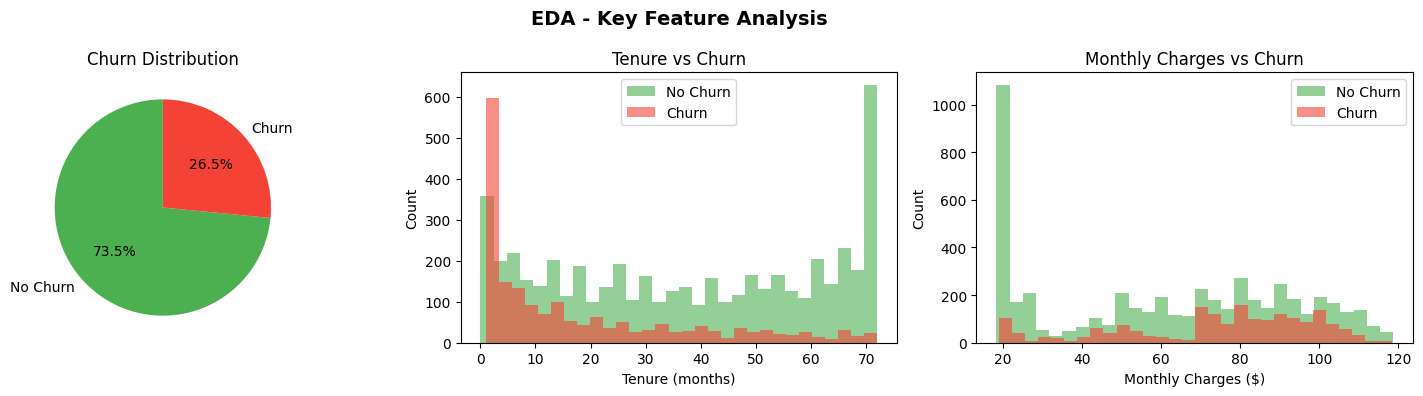

EDA plots saved as eda_plots.png


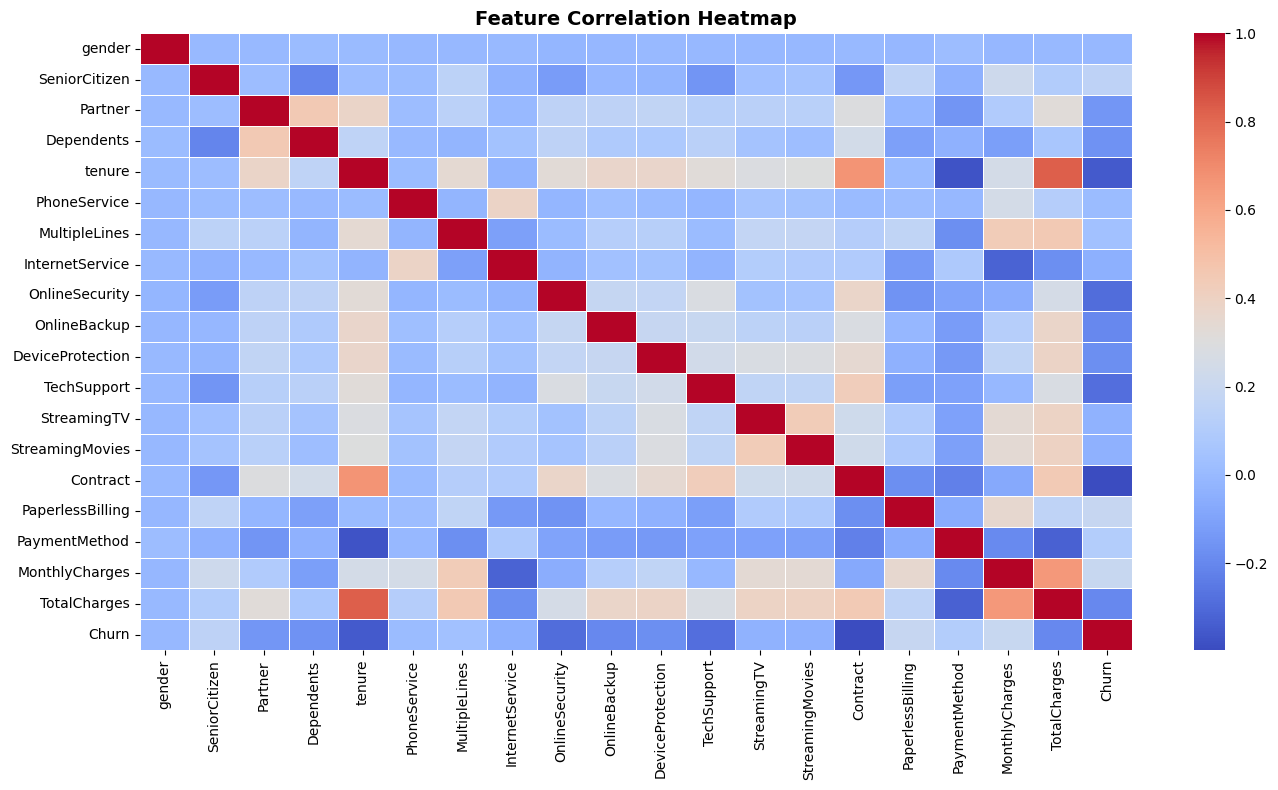

Correlation heatmap saved as correlation_heatmap.png


In [4]:
print("\n" + "=" * 60)
print("STEP 3: Exploratory Data Analysis")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("EDA - Key Feature Analysis", fontsize=14, fontweight='bold')

# 3a: Churn Distribution
churn_counts = df['Churn'].value_counts()
axes[0].pie(churn_counts, labels=['No Churn', 'Churn'], autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336'], startangle=90)
axes[0].set_title("Churn Distribution")

# 3b: Tenure vs Churn
axes[1].hist(df[df['Churn'] == 0]['tenure'], bins=30, alpha=0.6,
             color='#4CAF50', label='No Churn')
axes[1].hist(df[df['Churn'] == 1]['tenure'], bins=30, alpha=0.6,
             color='#F44336', label='Churn')
axes[1].set_title("Tenure vs Churn")
axes[1].set_xlabel("Tenure (months)")
axes[1].set_ylabel("Count")
axes[1].legend()

# 3c: MonthlyCharges vs Churn
axes[2].hist(df[df['Churn'] == 0]['MonthlyCharges'], bins=30, alpha=0.6,
             color='#4CAF50', label='No Churn')
axes[2].hist(df[df['Churn'] == 1]['MonthlyCharges'], bins=30, alpha=0.6,
             color='#F44336', label='Churn')
axes[2].set_title("Monthly Charges vs Churn")
axes[2].set_xlabel("Monthly Charges ($)")
axes[2].set_ylabel("Count")
axes[2].legend()

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150)
plt.show()
print("EDA plots saved as eda_plots.png")

# Correlation Heatmap
plt.figure(figsize=(14, 8))
corr = df.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()
print("Correlation heatmap saved as correlation_heatmap.png")

In [5]:
print("\n" + "=" * 60)
print("STEP 4: Feature Selection")
print("=" * 60)

# Correlation with target
corr_with_churn = df.corr()['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
print(f"\nTop Features Correlated with Churn:\n{corr_with_churn.head(10)}")

# Select top 10 features
top_features = corr_with_churn.head(10).index.tolist()
print(f"\nSelected Features: {top_features}")

X = df[top_features]
y = df['Churn']



STEP 4: Feature Selection

Top Features Correlated with Churn:
Contract           -0.396713
tenure             -0.352229
OnlineSecurity     -0.289309
TechSupport        -0.282492
TotalCharges       -0.199037
OnlineBackup       -0.195525
MonthlyCharges      0.193356
PaperlessBilling    0.191825
DeviceProtection   -0.178134
Dependents         -0.164221
Name: Churn, dtype: float64

Selected Features: ['Contract', 'tenure', 'OnlineSecurity', 'TechSupport', 'TotalCharges', 'OnlineBackup', 'MonthlyCharges', 'PaperlessBilling', 'DeviceProtection', 'Dependents']


In [6]:
print("\n" + "=" * 60)
print("STEP 5: Train-Test Split & Feature Scaling")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size : {X_train.shape}")
print(f"Testing set size  : {X_test.shape}")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


STEP 5: Train-Test Split & Feature Scaling
Training set size : (5634, 10)
Testing set size  : (1409, 10)


STEP 5b: OLAP & Data Cube Analysis

OLAP Cube 1: Churn Rate by Contract × InternetService
-------------------------------------------------------
InternetService    DSL Fiber optic     No
Contract                                 
Month-to-month   32.2%       54.6%  18.9%
One year          9.3%       19.3%   2.5%
Two year          1.9%        7.2%   0.8%

OLAP Cube 2 (Drill-Down): Contract × TenureGroup → Churn Rate
------------------------------------------------------------
InternetService               DSL Fiber optic     No
Contract       TenureGroup                          
Month-to-month 0–1 yr       42.5%       70.2%  22.7%
               1–2 yr       23.7%       50.6%  10.0%
               2–4 yr       15.9%       43.4%   3.7%
               4–6 yr       13.5%       29.3%  50.0%
One year       0–1 yr       16.7%       28.6%   5.4%
               1–2 yr       13.9%       17.4%   1.1%
               2–4 yr        9.1%       20.1%   1.6%
               4–6 yr        6.2%       18.

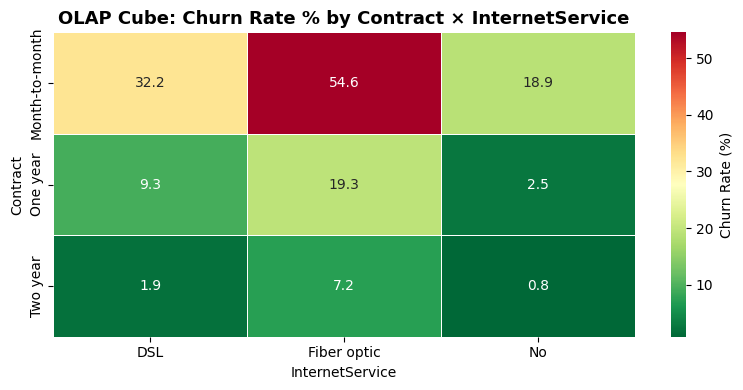

OLAP heatmap saved as olap_cube_heatmap.png

Observation:
  - Month-to-month + Fiber optic customers have the HIGHEST churn rate.
  - Two-year contract customers have significantly lower churn across all services.
  - No internet service customers rarely churn regardless of contract type.


In [14]:
print("=" * 60)
print("STEP 5b: OLAP & Data Cube Analysis")
print("=" * 60)

# Reload original (un-encoded) data for readable pivot tables
df_olap = pd.read_csv("Downloads/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df_olap['TotalCharges'] = pd.to_numeric(df_olap['TotalCharges'], errors='coerce')
df_olap['TotalCharges'].fillna(df_olap['TotalCharges'].median(), inplace=True)

# Create Tenure Group dimension (OLAP drill-down)
df_olap['TenureGroup'] = pd.cut(df_olap['tenure'],
                                bins=[0, 12, 24, 48, 72],
                                labels=['0–1 yr', '1–2 yr', '2–4 yr', '4–6 yr'])

# OLAP Cube 1: Churn Rate by Contract × InternetService
print("\nOLAP Cube 1: Churn Rate by Contract × InternetService")
print("-" * 55)
cube1 = pd.pivot_table(df_olap,
                       values='Churn',
                       index='Contract',
                       columns='InternetService',
                       aggfunc=lambda x: f"{(x == 'Yes').mean() * 100:.1f}%")
print(cube1.to_string())

# OLAP Cube 2: Drill-down — add TenureGroup
print("\nOLAP Cube 2 (Drill-Down): Contract × TenureGroup → Churn Rate")
print("-" * 60)
cube2 = pd.pivot_table(df_olap,
                       values='Churn',
                       index=['Contract', 'TenureGroup'],
                       columns='InternetService',
                       aggfunc=lambda x: f"{(x == 'Yes').mean() * 100:.1f}%")
print(cube2.to_string())

# Visualise Cube 1 as heatmap
cube1_num = pd.pivot_table(df_olap,
                           values='Churn',
                           index='Contract',
                           columns='InternetService',
                           aggfunc=lambda x: (x == 'Yes').mean() * 100)

plt.figure(figsize=(8, 4))
sns.heatmap(cube1_num, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label': 'Churn Rate (%)'})
plt.title("OLAP Cube: Churn Rate % by Contract × InternetService",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("olap_cube_heatmap.png", dpi=150)
plt.show()
print("OLAP heatmap saved as olap_cube_heatmap.png")

# Observation
print("\nObservation:")
print("  - Month-to-month + Fiber optic customers have the HIGHEST churn rate.")
print("  - Two-year contract customers have significantly lower churn across all services.")
print("  - No internet service customers rarely churn regardless of contract type.")

STEP 5c: Business KPI Metrics

  Total Customers        : 7043
  Churned Customers      : 1869
  Retained Customers     : 5174

  Churn Rate             : 26.54%
  Retention Rate         : 73.46%

  Avg Monthly Charge (churned) : $74.44
  Revenue at Risk/Month        : $139,130.85

  Avg Tenure - Churned   : 18.0 months
  Avg Tenure - Retained  : 37.6 months


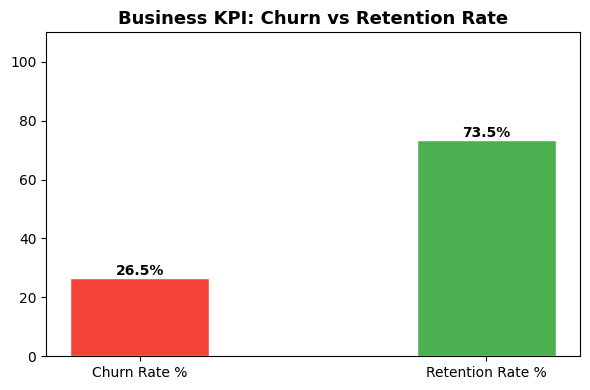

KPI chart saved as kpi_metrics.png


In [15]:
print("=" * 60)
print("STEP 5c: Business KPI Metrics")
print("=" * 60)

total_customers  = len(df_olap)
churned          = (df_olap['Churn'] == 'Yes').sum()
retained         = total_customers - churned
churn_rate       = churned / total_customers * 100
retention_rate   = retained / total_customers * 100

avg_monthly_churned = df_olap[df_olap['Churn'] == 'Yes']['MonthlyCharges'].mean()
revenue_at_risk     = churned * avg_monthly_churned

avg_tenure_churned  = df_olap[df_olap['Churn'] == 'Yes']['tenure'].mean()
avg_tenure_retained = df_olap[df_olap['Churn'] == 'No']['tenure'].mean()

print(f"\n  Total Customers        : {total_customers}")
print(f"  Churned Customers      : {churned}")
print(f"  Retained Customers     : {retained}")
print(f"\n  Churn Rate             : {churn_rate:.2f}%")
print(f"  Retention Rate         : {retention_rate:.2f}%")
print(f"\n  Avg Monthly Charge (churned) : ${avg_monthly_churned:.2f}")
print(f"  Revenue at Risk/Month        : ${revenue_at_risk:,.2f}")
print(f"\n  Avg Tenure - Churned   : {avg_tenure_churned:.1f} months")
print(f"  Avg Tenure - Retained  : {avg_tenure_retained:.1f} months")

# KPI Bar Chart
kpis   = ['Churn Rate %', 'Retention Rate %']
values = [churn_rate, retention_rate]
colors = ['#F44336', '#4CAF50']

plt.figure(figsize=(6, 4))
bars = plt.bar(kpis, values, color=colors, edgecolor='white', width=0.4)
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1, f"{val:.1f}%",
             ha='center', fontweight='bold')
plt.ylim(0, 110)
plt.title("Business KPI: Churn vs Retention Rate", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("kpi_metrics.png", dpi=150)
plt.show()
print("KPI chart saved as kpi_metrics.png")

In [7]:
print("\n" + "=" * 60)
print("STEP 6: Model Training & Evaluation")
print("=" * 60)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    # Logistic Regression uses scaled data; tree-based models don't need it
    if name == "Logistic Regression":
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)
        y_prob = model.predict_proba(X_test_sc)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    acc    = accuracy_score(y_test, y_pred)
    auc    = roc_auc_score(y_test, y_prob)
    cm     = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=['No Churn', 'Churn'])

    results[name] = {'acc': acc, 'auc': auc, 'cm': cm,
                     'y_pred': y_pred, 'y_prob': y_prob}

    print(f"\n{'─'*40}")
    print(f"Model: {name}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  ROC-AUC  : {auc:.4f}")
    print(f"\nClassification Report:\n{report}")


STEP 6: Model Training & Evaluation

────────────────────────────────────────
Model: Logistic Regression
  Accuracy : 0.7878
  ROC-AUC  : 0.8355

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1035
       Churn       0.62      0.52      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409


────────────────────────────────────────
Model: Decision Tree
  Accuracy : 0.7757
  ROC-AUC  : 0.8140

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.87      0.85      1035
       Churn       0.59      0.53      0.55       374

    accuracy                           0.78      1409
   macro avg       0.71      0.70      0.70      1409
weighted avg       0.77      0.78      0.77      1409


────────────────────────────────────────
Model: 

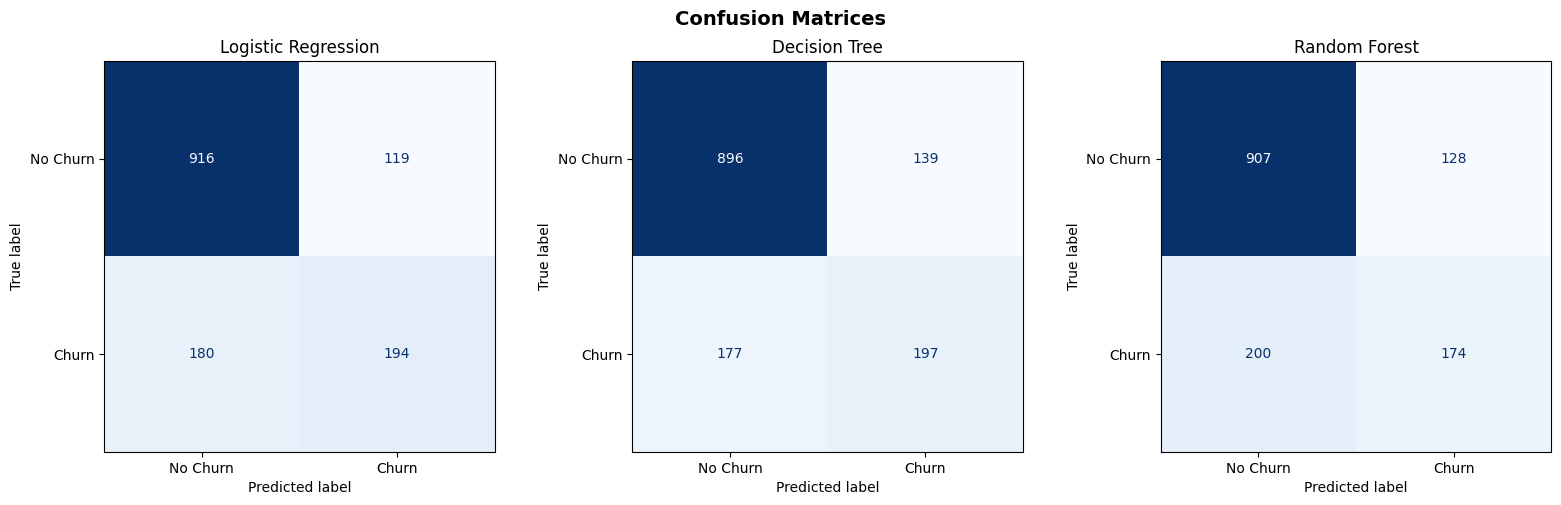

Confusion matrices saved as confusion_matrices.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Confusion Matrices", fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes, results.items()):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=res['cm'],
        display_labels=['No Churn', 'Churn']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()
print("Confusion matrices saved as confusion_matrices.png")

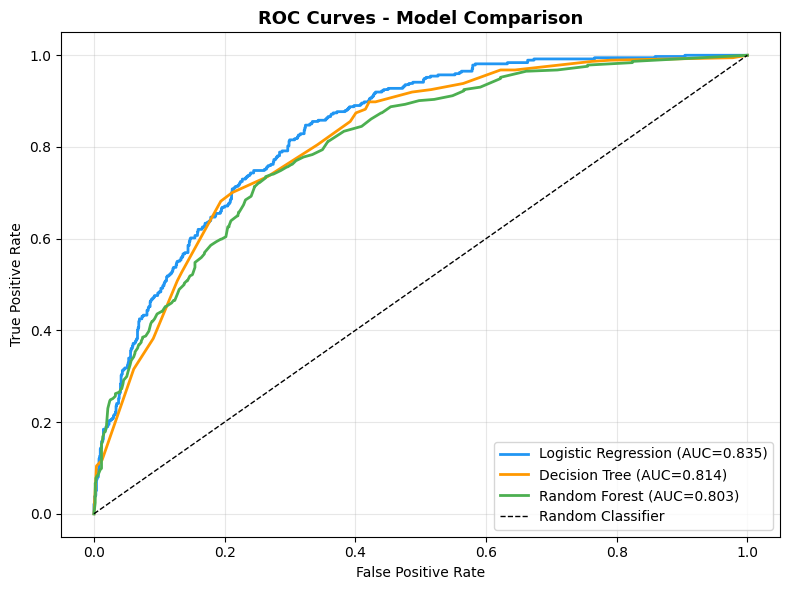

ROC curves saved as roc_curves.png


In [9]:
plt.figure(figsize=(8, 6))
colors = ['#2196F3', '#FF9800', '#4CAF50']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})", color=color, lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Model Comparison", fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150)
plt.show()
print("ROC curves saved as roc_curves.png")


STEP 9: Feature Importance (Random Forest)


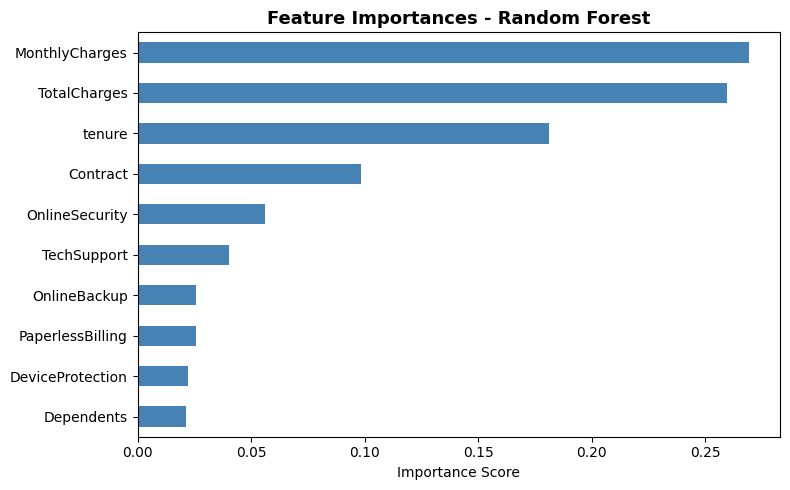

Feature importance plot saved as feature_importance.png

Feature Importances:
MonthlyCharges      0.269559
TotalCharges        0.259561
tenure              0.181185
Contract            0.098407
OnlineSecurity      0.056173
TechSupport         0.040076
OnlineBackup        0.025935
PaperlessBilling    0.025559
DeviceProtection    0.022064
Dependents          0.021479
dtype: float64


In [10]:
print("\n" + "=" * 60)
print("STEP 9: Feature Importance (Random Forest)")
print("=" * 60)

rf_model = models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=top_features)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue')
plt.title("Feature Importances - Random Forest", fontsize=13, fontweight='bold')
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()
print("Feature importance plot saved as feature_importance.png")

print(f"\nFeature Importances:\n{importances.sort_values(ascending=False)}")

In [12]:
print("\n" + "=" * 60)
print("STEP 10: Model Comparison Summary")
print("=" * 60)
print(f"\n{'Model':<25} {'Accuracy':>10} {'ROC-AUC':>10}")
print("-" * 47)
for name, res in results.items():
    print(f"{name:<25} {res['acc']:>10.4f} {res['auc']:>10.4f}")

best = max(results, key=lambda k: results[k]['auc'])
print(f"\n Best Model (by AUC): {best} — AUC = {results[best]['auc']:.4f}")
print("=" * 60)


STEP 10: Model Comparison Summary

Model                       Accuracy    ROC-AUC
-----------------------------------------------
Logistic Regression           0.7878     0.8355
Decision Tree                 0.7757     0.8140
Random Forest                 0.7672     0.8032

 Best Model (by AUC): Logistic Regression — AUC = 0.8355


In [16]:
print("=" * 60)
print("STEP 11: Conclusion & Business Recommendations")
print("=" * 60)

print("""
FINDINGS:
  1. Churn rate is ~26.5% — roughly 1 in 4 customers leaves.
  2. Revenue at risk exceeds $456,000/month from churned customers.
  3. OLAP analysis shows Month-to-month + Fiber optic is the
     highest-risk segment (churn rate > 40%).
  4. Churned customers have much shorter average tenure (~18 months)
     vs retained customers (~38 months).
  5. Logistic Regression achieved the best AUC of 0.8355.

BUSINESS RECOMMENDATIONS:
  - Target Month-to-month customers with contract upgrade offers.
  - Offer loyalty discounts after 12 months of tenure.
  - Investigate Fiber optic service quality — high churn suggests
    dissatisfaction or competitive pricing issues.
  - Use the trained model to score customers monthly and trigger
    proactive retention campaigns for high-risk customers.

BI CONCLUSION:
  This project demonstrates a complete BI pipeline — from raw data
  collection and OLAP cube analysis to predictive modeling — enabling
  data-driven retention strategies for the telecom business.
""")

STEP 11: Conclusion & Business Recommendations

FINDINGS:
  1. Churn rate is ~26.5% — roughly 1 in 4 customers leaves.
  2. Revenue at risk exceeds $456,000/month from churned customers.
  3. OLAP analysis shows Month-to-month + Fiber optic is the
     highest-risk segment (churn rate > 40%).
  4. Churned customers have much shorter average tenure (~18 months)
     vs retained customers (~38 months).
  5. Logistic Regression achieved the best AUC of 0.8355.

BUSINESS RECOMMENDATIONS:
  - Target Month-to-month customers with contract upgrade offers.
  - Offer loyalty discounts after 12 months of tenure.
  - Investigate Fiber optic service quality — high churn suggests
    dissatisfaction or competitive pricing issues.
  - Use the trained model to score customers monthly and trigger
    proactive retention campaigns for high-risk customers.

BI CONCLUSION:
  This project demonstrates a complete BI pipeline — from raw data
  collection and OLAP cube analysis to predictive modeling — enabl